# Визуализация на Сегментацията (Sliding Window Effect)

За да проверим качеството на нашата сегментация, ще визуализираме оригиналния сигнал и неговите новосъздадени 2-секундни сегменти. 
Тъй като използваме **50% застъпване (overlap)**, очакваме да видим как краят на Сегмент 1 съвпада с началото на Сегмент 2. Визуализацията е чрез Мел-спектрограми, тъй като това са реалните данни, които нашата CNN мрежа ще "вижда".

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import pandas as pd
import librosa
import soundfile as sf
from tqdm import tqdm
from src.data_processing.segment_audio import segment_audio
from src.data_processing.clean_audio import load_and_clean_audio

# Пътища
ORIGINAL_CSV = "../data/raw/ESC-50-master/meta/esc50.csv"
AUDIO_DIR = "../data/raw/ESC-50-master/audio/"

# Нови пътища за сегментираните данни
SEGMENTED_AUDIO_DIR = "../data/processed/segmented_audio/"
SEGMENTED_CSV = "../data/processed/esc50_segmented.csv"

os.makedirs(SEGMENTED_AUDIO_DIR, exist_ok=True)

df = pd.read_csv(ORIGINAL_CSV)
new_rows = []

print("Започва сегментиране на аудио файловете...")
for index, row in tqdm(df.iterrows(), total=len(df)):
    original_filename = row['filename']
    file_path = os.path.join(AUDIO_DIR, original_filename)
    
    # 1. Зареждаме и премахваме тишината
    y, sr = load_and_clean_audio(file_path, sr=22050, top_db=20)
    
    # 2. Нарязваме го на сегменти с 50% застъпване
    segments = segment_audio(y, sr, segment_duration=2.0, overlap=0.5)
    
    # 3. Запазваме всеки сегмент като отделен файл
    for i, segment in enumerate(segments):
        # Ново име: 1-100032-A-0_seg0.wav
        new_filename = original_filename.replace('.wav', f'_seg{i}.wav')
        new_filepath = os.path.join(SEGMENTED_AUDIO_DIR, new_filename)
        
        # Записваме аудиото на диска
        sf.write(new_filepath, segment, sr)
        
        # Копираме оригиналните метаданни, но с новото име на файла
        new_row = row.copy()
        new_row['filename'] = new_filename
        new_rows.append(new_row)

# Създаваме новия DataFrame и го запазваме
new_df = pd.DataFrame(new_rows)
new_df.to_csv(SEGMENTED_CSV, index=False)

print(f"Готово! Оригинални файлове: {len(df)} -> Сегментирани файлове: {len(new_df)}")

Започва сегментиране на аудио файловете...


100%|██████████| 2000/2000 [00:10<00:00, 189.42it/s]


Готово! Оригинални файлове: 2000 -> Сегментирани файлове: 5830


## Визуализация на Сегментацията (Sliding Window Effect)

За да проверим качеството на нашата сегментация, ще визуализираме оригиналния сигнал и неговите новосъздадени 2-секундни сегменти. 
Тъй като използваме **50% застъпване (overlap)**, очакваме да видим как краят на Сегмент 1 съвпада с началото на Сегмент 2. Визуализацията е чрез Мел-спектрограми, тъй като това са реалните данни, които нашата CNN мрежа ще "вижда".

Оригинален файл: 1-100032-A-0.wav
Намерени сегменти: 1


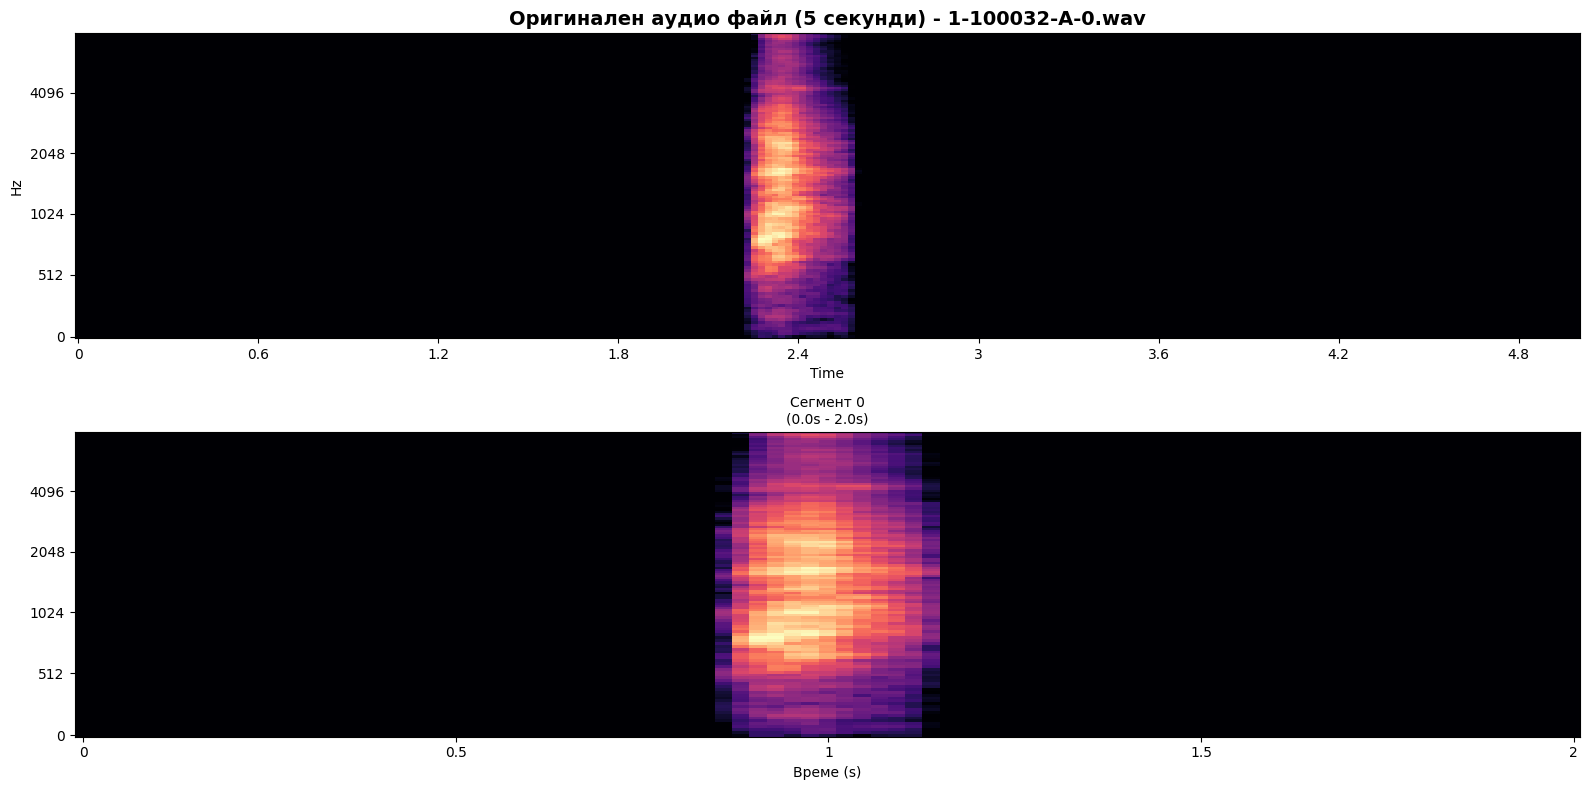

In [2]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import glob
import os
import numpy as np
# Пътища до папките
ORIGINAL_AUDIO_DIR = "../data/raw/ESC-50-master/audio/"
SEGMENTED_AUDIO_DIR = "../data/processed/segmented_audio/"

# 1. Избираме един интересен оригинален файл (напр. сирена, куче или хеликоптер)
# Можеш да смениш името с някое реално от твоята папка
sample_original_file = "1-100032-A-0.wav" # Замени с реален файл от ESC-50, ако този го няма
original_path = os.path.join(ORIGINAL_AUDIO_DIR, sample_original_file)

# 2. Намираме всички негови сегменти в новата папка
search_pattern = os.path.join(SEGMENTED_AUDIO_DIR, sample_original_file.replace('.wav', '_seg*.wav'))
segmented_files = sorted(glob.glob(search_pattern))

print(f"Оригинален файл: {sample_original_file}")
print(f"Намерени сегменти: {len(segmented_files)}")

# Функция за бързо вадене на Мел-спектрограма
def get_mel(filepath):
    y, sr = librosa.load(filepath, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    return librosa.power_to_db(mel, ref=np.max)

# 3. Визуализация
if len(segmented_files) > 0:
    fig = plt.figure(figsize=(16, 8))
    
    # Плотваме оригинала най-отгоре (заема цялата ширина)
    ax_main = plt.subplot(2, 1, 1)
    mel_orig = get_mel(original_path)
    librosa.display.specshow(mel_orig, sr=22050, x_axis='time', y_axis='mel', fmax=8000, ax=ax_main, cmap='magma')
    ax_main.set_title(f"Оригинален аудио файл (5 секунди) - {sample_original_file}", fontsize=14, fontweight='bold')
    
    # Плотваме сегментите отдолу
    num_segs = len(segmented_files)
    for i, seg_file in enumerate(segmented_files):
        ax = plt.subplot(2, num_segs, num_segs + i + 1)
        mel_seg = get_mel(seg_file)
        librosa.display.specshow(mel_seg, sr=22050, x_axis='time', y_axis='mel', fmax=8000, ax=ax, cmap='magma')
        
        # Изчисляваме времевия прозорец за заглавието
        start_time = i * 1.0 # Защото стъпката е 1 секунда (при 50% overlap на 2 сек)
        end_time = start_time + 2.0
        ax.set_title(f"Сегмент {i}\n({start_time}s - {end_time}s)", fontsize=10)
        ax.set_xlabel('Време (s)')
        ax.set_ylabel('') # Скриваме оста Y за по-чист вид на малките графики
        
    plt.tight_layout()
    plt.show()
else:
    print("Не са намерени сегментирани файлове. Провери дали скриптът за сегментация е приключил успешно.")